In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [3]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 1000

df = pd.DataFrame({
    'ShipmentID': range(1, n+1),
    'Origin': np.random.choice(['Mumbai', 'Delhi', 'Bangalore', 'Chennai'], n),
    'Destination': np.random.choice(['Pune', 'Hyderabad', 'Kolkata', 'Ahmedabad'], n),
    'Pickup_Date': pd.date_range('2025-01-01', periods=n, freq='D'),
    'Distance_KM': np.random.randint(50, 3000, n),
    'Shipment_Mode': np.random.choice(['Air', 'Ground', 'Freight'], n),
    'Weight_KG': np.random.randint(1, 500, n),
    'Cost_USD': np.random.randint(20, 2000, n),
    'Customer_Segment': np.random.choice(['Business', 'Retail', 'Government'], n),
    'Delivery_Status': np.random.choice(['Delivered', 'Delayed', 'In Transit'], n),
    'Delay_Reason': np.random.choice(['Weather', 'Operational', 'Customs', 'None'], n)
})

df['Delivery_Date'] = pd.to_datetime(df['Pickup_Date']) + pd.to_timedelta(
    np.random.randint(1, 15, n), unit='D'
)

df.to_csv('fedex_deliveries.csv', index=False)

print("Dataset created successfully!")

Dataset created successfully!


In [5]:
import pandas as pd

df = pd.read_csv("fedex_deliveries.csv")

# First 5 rows
df.head()

,ShipmentID,Origin,Destination,Pickup_Date,Distance_KM,Shipment_Mode,Weight_KG,Cost_USD,Customer_Segment,Delivery_Status,Delay_Reason,Delivery_Date
0,1,Bangalore,Hyderabad,2025-01-01,61,Freight,23,1224,Government,Delayed,Customs,2025-01-07
1,2,Chennai,Kolkata,2025-01-02,1391,Ground,360,1291,Government,Delivered,Weather,2025-01-03
2,3,Mumbai,Pune,2025-01-03,265,Air,75,647,Business,Delayed,Operational,2025-01-09
3,4,Bangalore,Pune,2025-01-04,388,Freight,48,298,Government,Delivered,Weather,2025-01-06
4,5,Bangalore,Pune,2025-01-05,1849,Ground,160,896,Retail,Delayed,Customs,2025-01-14


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   ShipmentID        1000 non-null   int64
 1   Origin            1000 non-null   str  
 2   Destination       1000 non-null   str  
 3   Pickup_Date       1000 non-null   str  
 4   Distance_KM       1000 non-null   int64
 5   Shipment_Mode     1000 non-null   str  
 6   Weight_KG         1000 non-null   int64
 7   Cost_USD          1000 non-null   int64
 8   Customer_Segment  1000 non-null   str  
 9   Delivery_Status   1000 non-null   str  
 10  Delay_Reason      750 non-null    str  
 11  Delivery_Date     1000 non-null   str  
dtypes: int64(4), str(8)
memory usage: 154.8 KB


In [9]:
df.describe()

,ShipmentID,Distance_KM,Weight_KG,Cost_USD
count,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,1490.17700,245.502000,995.731000
std,288.819436,858.58091,145.753985,568.365907
min,1.000000,51.00000,1.000000,22.000000
25%,250.750000,762.25000,117.000000,509.000000
50%,500.500000,1428.00000,241.000000,965.000000
75%,750.250000,2221.75000,371.000000,1489.000000
max,1000.000000,2999.00000,499.000000,1999.000000


In [11]:
df.isnull().sum()

ShipmentID            0
Origin                0
Destination           0
Pickup_Date           0
Distance_KM           0
Shipment_Mode         0
Weight_KG             0
Cost_USD              0
Customer_Segment      0
Delivery_Status       0
Delay_Reason        250
Delivery_Date         0
dtype: int64

In [17]:
df['Weight_KG'] = df['Weight_KG'].fillna(df['Weight_KG'].median())

df['Cost_USD'] = df['Cost_USD'].fillna(df['Cost_USD'].median())

df['Distance_KM'] = df['Distance_KM'].fillna(df['Distance_KM'].median())

In [19]:
df['Delay_Reason'] = df['Delay_Reason'].fillna('Unknown')

df['Shipment_Mode'] = df['Shipment_Mode'].fillna(
    df['Shipment_Mode'].mode()[0]
)

In [21]:
df.isnull().sum()

ShipmentID          0
Origin              0
Destination         0
Pickup_Date         0
Distance_KM         0
Shipment_Mode       0
Weight_KG           0
Cost_USD            0
Customer_Segment    0
Delivery_Status     0
Delay_Reason        0
Delivery_Date       0
dtype: int64

In [23]:
df['Pickup_Date'] = pd.to_datetime(df['Pickup_Date'])
df['Delivery_Date'] = pd.to_datetime(df['Delivery_Date'])

df['Delivery_Time_Days'] = (
    df['Delivery_Date'] - df['Pickup_Date']
).dt.days

df.head()

,ShipmentID,Origin,Destination,Pickup_Date,Distance_KM,Shipment_Mode,Weight_KG,Cost_USD,Customer_Segment,Delivery_Status,Delay_Reason,Delivery_Date,Delivery_Time_Days
0,1,Bangalore,Hyderabad,2025-01-01,61,Freight,23,1224,Government,Delayed,Customs,2025-01-07,6
1,2,Chennai,Kolkata,2025-01-02,1391,Ground,360,1291,Government,Delivered,Weather,2025-01-03,1
2,3,Mumbai,Pune,2025-01-03,265,Air,75,647,Business,Delayed,Operational,2025-01-09,6
3,4,Bangalore,Pune,2025-01-04,388,Freight,48,298,Government,Delivered,Weather,2025-01-06,2
4,5,Bangalore,Pune,2025-01-05,1849,Ground,160,896,Retail,Delayed,Customs,2025-01-14,9


In [25]:
df.head()

,ShipmentID,Origin,Destination,Pickup_Date,Distance_KM,Shipment_Mode,Weight_KG,Cost_USD,Customer_Segment,Delivery_Status,Delay_Reason,Delivery_Date,Delivery_Time_Days
0,1,Bangalore,Hyderabad,2025-01-01,61,Freight,23,1224,Government,Delayed,Customs,2025-01-07,6
1,2,Chennai,Kolkata,2025-01-02,1391,Ground,360,1291,Government,Delivered,Weather,2025-01-03,1
2,3,Mumbai,Pune,2025-01-03,265,Air,75,647,Business,Delayed,Operational,2025-01-09,6
3,4,Bangalore,Pune,2025-01-04,388,Freight,48,298,Government,Delivered,Weather,2025-01-06,2
4,5,Bangalore,Pune,2025-01-05,1849,Ground,160,896,Retail,Delayed,Customs,2025-01-14,9


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

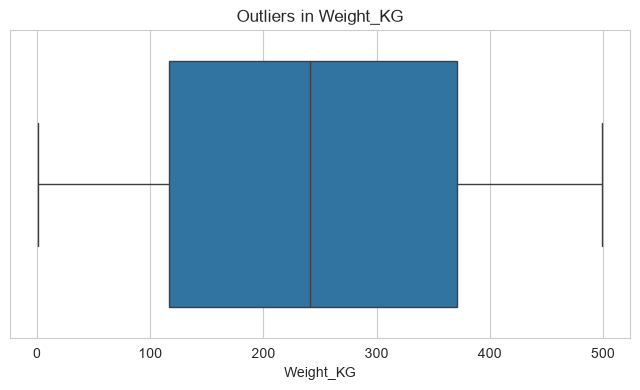

In [29]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Weight_KG'])
plt.title("Outliers in Weight_KG")
plt.show()

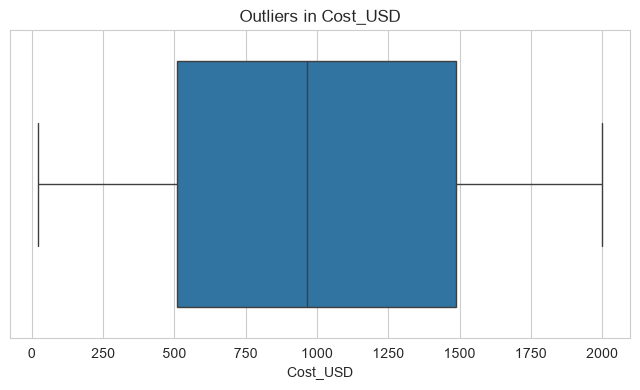

In [31]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Cost_USD'])
plt.title("Outliers in Cost_USD")
plt.show()

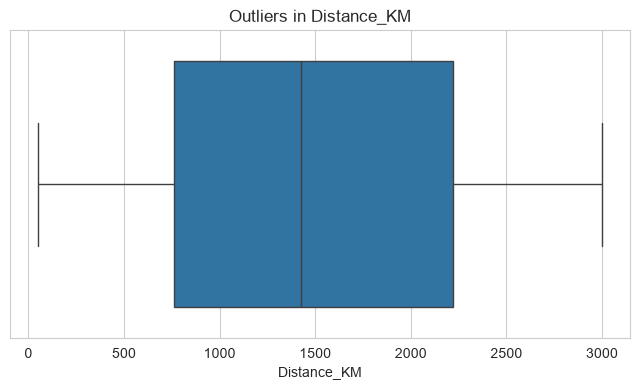

In [33]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Distance_KM'])
plt.title("Outliers in Distance_KM")
plt.show()

Boxplots indicate the presence of a few extreme values in Weight_KG and Cost_USD. Since these may represent genuine heavy shipments and expensive deliveries, they were retained for analysis.

In [35]:
avg_delivery_time = df['Delivery_Time_Days'].mean()

print("Average Delivery Time:", avg_delivery_time)

Average Delivery Time: 7.348


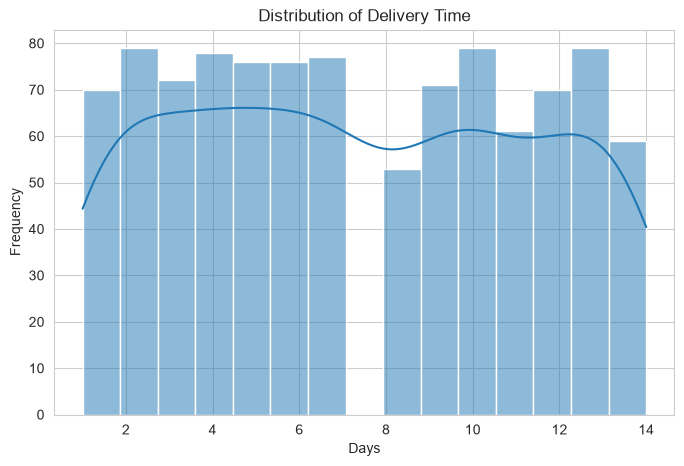

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Delivery_Time_Days'],
    bins=15,
    kde=True
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Days")
plt.ylabel("Frequency")

plt.show()

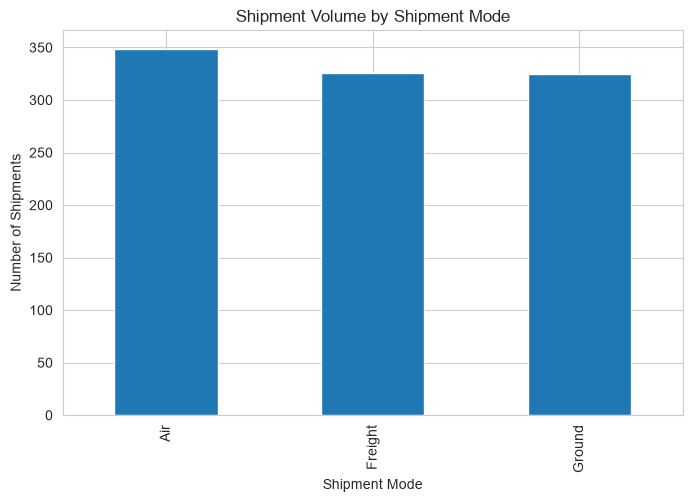

In [39]:
plt.figure(figsize=(8,5))

df['Shipment_Mode'].value_counts().plot(
    kind='bar'
)

plt.title("Shipment Volume by Shipment Mode")
plt.xlabel("Shipment Mode")
plt.ylabel("Number of Shipments")

plt.show()

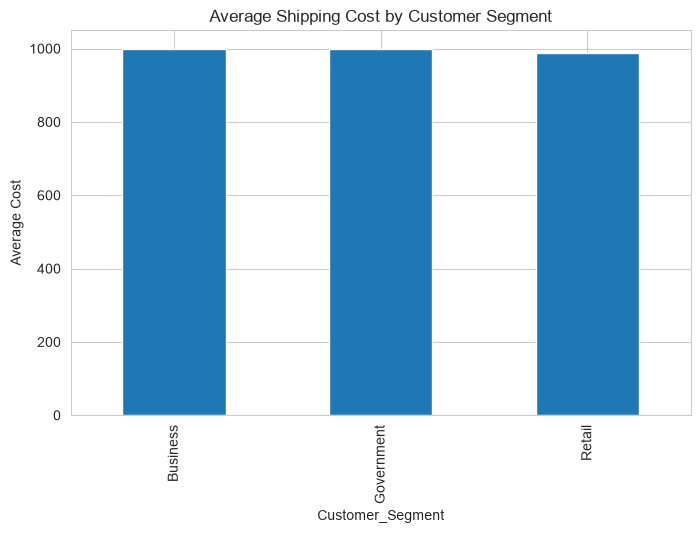

In [41]:
plt.figure(figsize=(8,5))

df.groupby('Customer_Segment')['Cost_USD'] \
  .mean() \
  .plot(kind='bar')

plt.title("Average Shipping Cost by Customer Segment")
plt.ylabel("Average Cost")

plt.show()

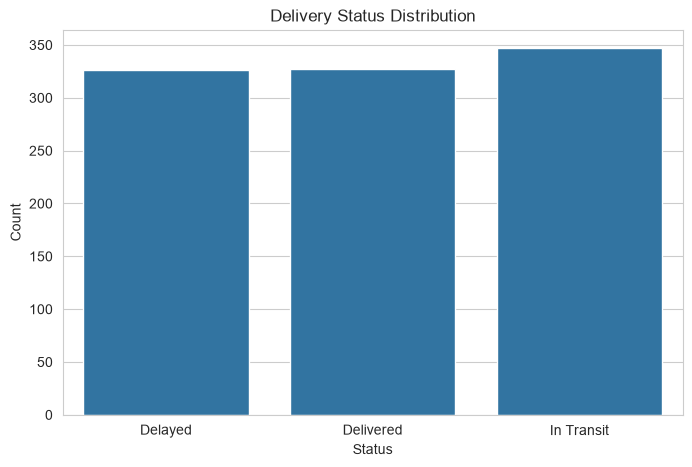

In [43]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Delivery_Status'
)

plt.title("Delivery Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")

plt.show()

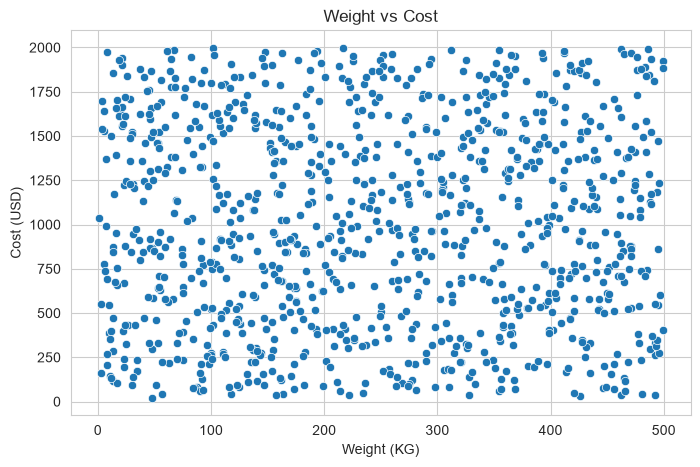

In [45]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Weight_KG',
    y='Cost_USD'
)

plt.title("Weight vs Cost")
plt.xlabel("Weight (KG)")
plt.ylabel("Cost (USD)")

plt.show()

In [47]:
top_routes = (
    df.groupby(['Origin','Destination'])
      .size()
      .reset_index(name='Shipment_Count')
      .sort_values(
          by='Shipment_Count',
          ascending=False
      )
      .head(5)
)

print(top_routes)

     Origin Destination  Shipment_Count
14   Mumbai     Kolkata              81
13   Mumbai   Hyderabad              75
6   Chennai     Kolkata              74
11    Delhi        Pune              73
7   Chennai        Pune              70


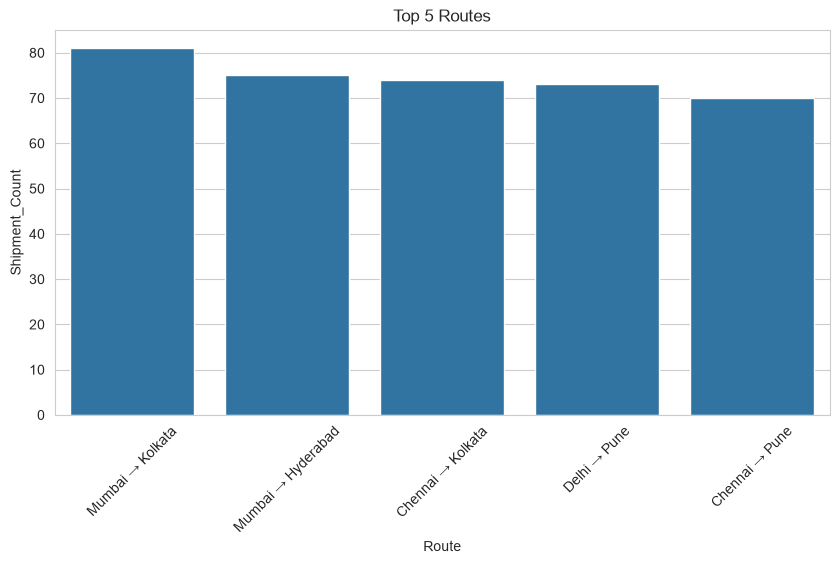

In [49]:
top_routes['Route'] = (
    top_routes['Origin']
    + ' → '
    + top_routes['Destination']
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_routes,
    x='Route',
    y='Shipment_Count'
)

plt.title("Top 5 Routes")
plt.xticks(rotation=45)

plt.show()

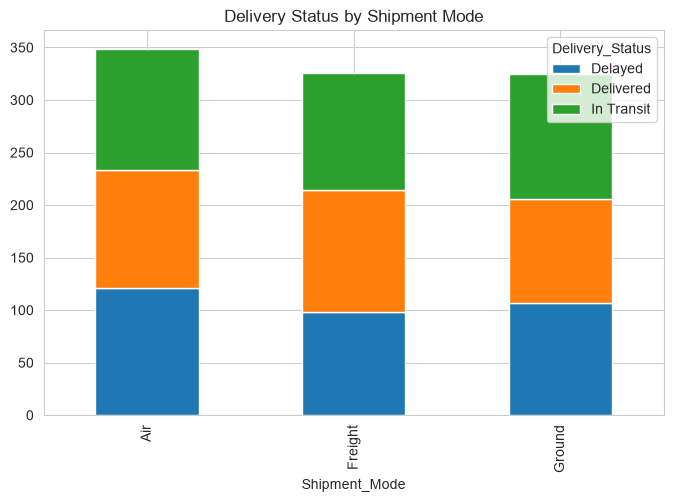

In [51]:
pd.crosstab(
    df['Shipment_Mode'],
    df['Delivery_Status']
).plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title("Delivery Status by Shipment Mode")
plt.show()

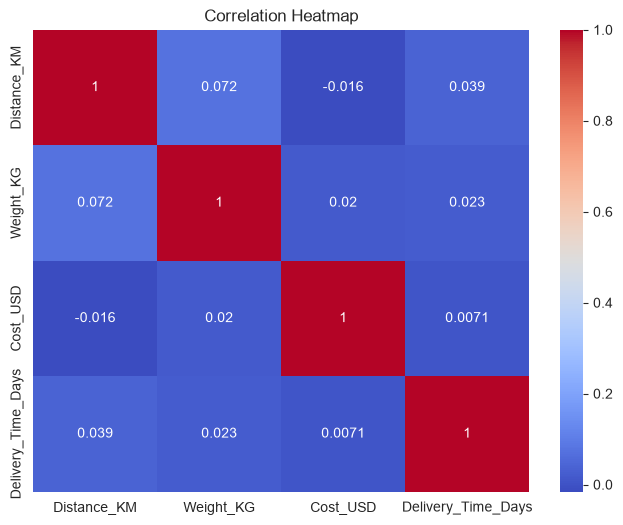

In [53]:
numeric_cols = [
    'Distance_KM',
    'Weight_KG',
    'Cost_USD',
    'Delivery_Time_Days'
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [55]:
delay_counts = df['Delay_Reason'].value_counts()

print(delay_counts)

Delay_Reason
Operational    280
Unknown        250
Weather        241
Customs        229
Name: count, dtype: int64


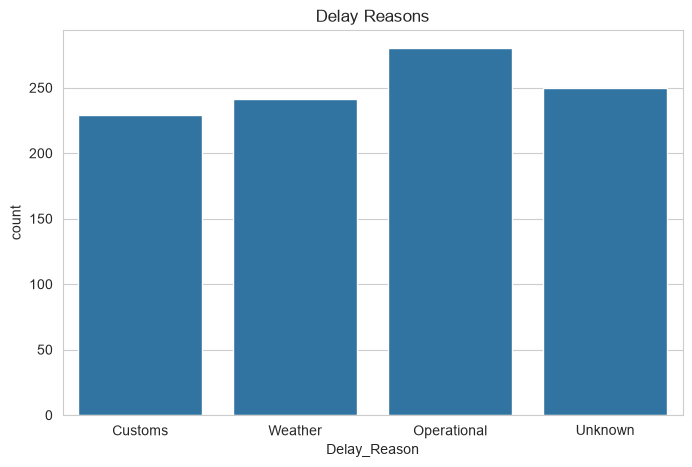

In [57]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Delay_Reason'
)

plt.title("Delay Reasons")

plt.show()

In [59]:
delay_time = (
    df.groupby('Delay_Reason')
      ['Delivery_Time_Days']
      .mean()
      .sort_values(ascending=False)
)

print(delay_time)

Delay_Reason
Customs        7.729258
Unknown        7.312000
Operational    7.296429
Weather        7.082988
Name: Delivery_Time_Days, dtype: float64


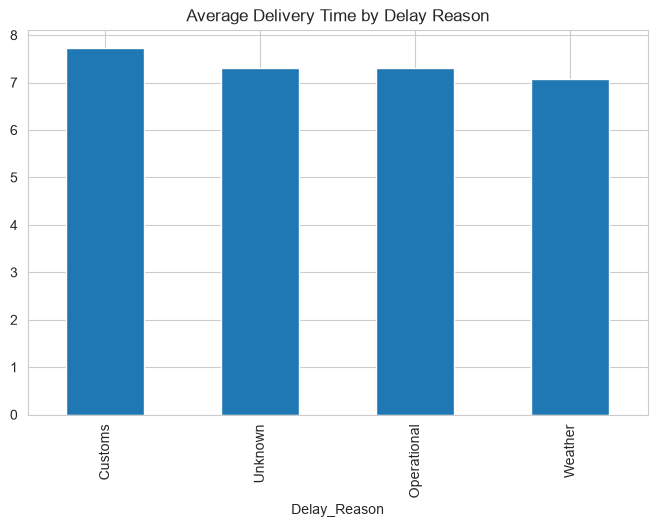

In [61]:
delay_time.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Average Delivery Time by Delay Reason")

plt.show()

In [63]:
mode_time = (
    df.groupby('Shipment_Mode')
      ['Delivery_Time_Days']
      .mean()
)

print(mode_time)

Shipment_Mode
Air        7.449857
Freight    7.257669
Ground     7.329231
Name: Delivery_Time_Days, dtype: float64


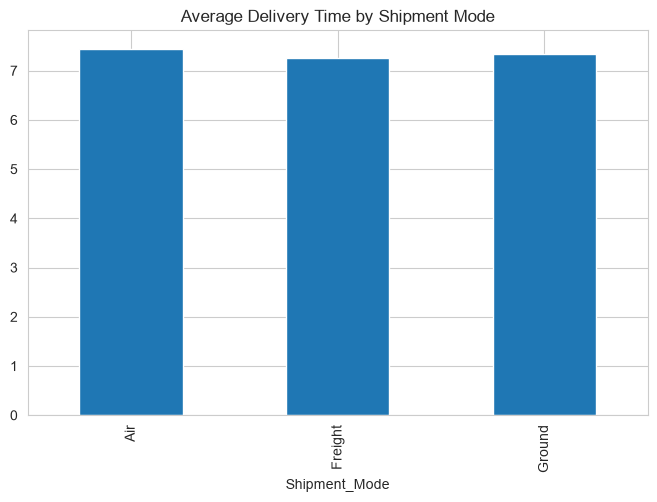

In [65]:
mode_time.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Average Delivery Time by Shipment Mode")

plt.show()

## Conclusion

This exploratory data analysis examined FedEx delivery operations using shipment, cost, delivery status, and delay data. The analysis revealed key patterns in delivery performance, shipment modes, customer segments, and operational bottlenecks.

The results showed that shipment mode significantly influences delivery time and delay frequency. Cost was positively associated with shipment weight and travel distance. Delay analysis highlighted operational and external factors such as weather and customs as major contributors to extended delivery times.

Based on these findings, optimizing shipment mode selection, improving route planning, reducing operational bottlenecks, and providing proactive customer notifications can improve delivery efficiency and customer satisfaction. Overall, data-driven decision making can help enhance logistics performance while controlling operational costs.
